In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

archivo = "precios-de-gas-natural-CLEANED.csv"
gas_df = pd.read_csv(archivo)

In [ ]:
# info del dataset
gas_df.info()
# gas_df.describe()
# gas_df.head(10)

# ejercicio 1
# en el dataset existen 7 variables, 444 entradas

# lista de cuencas
cuencas = gas_df["cuenca"].unique()

cuencas
# existen 5 cuencas (sin contar 'total cuenca') en el dataset: ['Austral Santa Cruz' 'Austral Tierra del Fuego' 'Golfo de San Jorge'
# 'Neuquina' 'Noroeste' 'Total Cuenca']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 444 entries, 0 to 443
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   anio                444 non-null    int64  
 1   mes                 444 non-null    int64  
 2   cuenca              444 non-null    object 
 3   precio_gnc          444 non-null    float64
 4   precio_usina        444 non-null    float64
 5   precio_industria    444 non-null    float64
 6   precio_exportacion  444 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 24.4+ KB


array(['Austral Santa Cruz', 'Austral Tierra del Fuego',
       'Golfo de San Jorge', 'Neuquina', 'Noroeste', 'Total Cuenca'],
      dtype=object)

In [ ]:
# %%
# EJERCICIO 2
def obtener_precios_cuenca_anio(df, cuenca, anio):
  try:
    # lee el dataset
    df = pd.read_csv(df)

    # filtra por cuenca y anio
    filtro = (df['cuenca'] == cuenca) & (df['anio'] == anio)
    df_filtrado = df[filtro]

    # si dataframe esta vacio
    if df_filtrado.empty:
      print(f"No se encontraron datos para la cuenca '{cuenca}' en el año {anio}.")
      return None
    else:
      return df_filtrado
  except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")
    return None

obtener_precios_cuenca_anio(archivo, 'Austral Tierra del Fuego', 2019)


,anio,mes,cuenca,precio_gnc,precio_usina,precio_industria,precio_exportacion
1,2019,1,Austral Tierra del Fuego,3.33,2.81,3.36,3.49
7,2019,2,Austral Tierra del Fuego,3.19,2.66,3.48,3.22
13,2019,3,Austral Tierra del Fuego,2.93,2.54,3.20,2.72
19,2019,4,Austral Tierra del Fuego,3.01,2.79,3.05,3.34
25,2019,5,Austral Tierra del Fuego,3.61,2.45,3.11,3.21
31,2019,6,Austral Tierra del Fuego,3.30,2.65,3.22,3.21
37,2019,7,Austral Tierra del Fuego,2.70,2.63,3.13,3.21
43,2019,8,Austral Tierra del Fuego,2.83,2.48,3.21,0.00
49,2019,9,Austral Tierra del Fuego,2.76,2.08,2.87,0.00
55,2019,10,Austral Tierra del Fuego,2.66,2.04,2.08,3.21


In [ ]:
# %%
# EJERCICIO 3

def analizar_precios_tipo(df, tipo_precio, cuenca):
  """La función debe retornar un diccionario con:
  - 'precio_promedio': precio promedio histórico
  - 'precio_maximo': precio máximo registrado
  - 'precio_minimo': precio mínimo registrado (excluyendo valores 0)
  - 'fecha_maximo': tupla (año, mes) cuando se registró el precio máximo"""

  df = pd.read_csv(df)
  dict_resultado = {
      "precio_promedio":0,
      "precio_maximo":0,
      "precio_minimo":0,
      "fecha_maximo":0
      }

  tipo_precio_lista = {
      'gnc':"precio_gnc",
      'usina':"precio_usina",
      'industria':"precio_industria",
      'exportacion':"precio_exportacion"
      }

  # verificar que el tipo de precio sea correcto
  if tipo_precio not in tipo_precio_lista.keys():
    print("el parametro 'tipo_precio' no es admitido")
  else:
    tipo_precio = tipo_precio_lista[tipo_precio]

    # filtramos la cuenca seleccionada
    df_filtrado = df[(df['cuenca'] == cuenca)]
    # print(df_filtrado)

    # precio promedio
    precio_promedio = df_filtrado[tipo_precio].mean()
    # precio maximo
    precio_maximo = df_filtrado[tipo_precio].max()
    # precio_minimo
    precio_minimo = df_filtrado[tipo_precio].min()

    # tomamos la fila del precio maximo
    df_max = df_filtrado[df_filtrado[tipo_precio] == precio_maximo]
    print(df_max)

    if not df_max.empty:
      # tomamos el primer resultado del df del precio maximo
      anio = int(df_max.iloc[0]['anio'])
      mes = int(df_max.iloc[0]['mes'])
      fecha_maximo = (anio, mes)
    else:
      fecha_maximo = None

    dict_resultado["precio_promedio"] = precio_promedio
    dict_resultado["precio_maximo"] = precio_maximo
    dict_resultado["precio_minimo"] = precio_minimo
    dict_resultado["fecha_maximo"] = fecha_maximo

    return dict_resultado

analizar_precios_tipo(archivo, "gnc", "Austral Tierra del Fuego")

     anio  mes                    cuenca  precio_gnc  precio_usina  \
421  2024   11  Austral Tierra del Fuego        4.18          3.05   

     precio_industria  precio_exportacion  
421              2.01                3.25  


{'precio_promedio': np.float64(3.0017567567567567),
 'precio_maximo': 4.18,
 'precio_minimo': 1.54,
 'fecha_maximo': (2024, 11)}

2.979594594594595 4.87 1.29


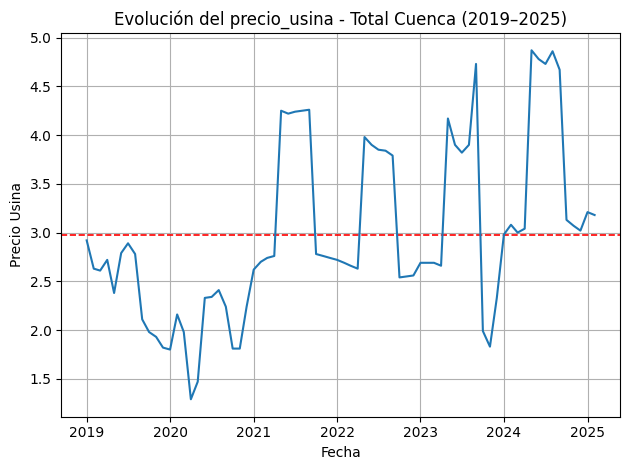

,anio,mes,cuenca,precio_gnc,precio_usina,precio_industria,precio_exportacion,fecha
5,2019,1,Total Cuenca,3.58,2.92,3.63,3.92,2019-01-01
11,2019,2,Total Cuenca,3.36,2.63,3.62,4.44,2019-02-01
17,2019,3,Total Cuenca,3.21,2.61,3.60,4.07,2019-03-01
23,2019,4,Total Cuenca,3.36,2.72,3.51,4.19,2019-04-01
29,2019,5,Total Cuenca,3.95,2.38,3.80,3.98,2019-05-01
...,...,...,...,...,...,...,...,...
419,2024,10,Total Cuenca,3.80,3.13,2.13,4.60,2024-10-01
425,2024,11,Total Cuenca,4.26,3.07,2.18,4.54,2024-11-01
431,2024,12,Total Cuenca,4.16,3.02,2.12,4.27,2024-12-01
437,2025,1,Total Cuenca,4.10,3.21,2.11,3.95,2025-01-01


In [ ]:
# %%
# EJERCICIO 4
"""Crear un gráfico de líneas que muestre la evolución temporal de precio_usina
para "Total Cuenca" desde 2019 hasta 2025. Para esto:
a) Filtrar los datos solo para "Total Cuenca"
b) Crear una columna 'fecha' combinando año y mes
c) Graficar precio_usina vs. tiempo con etiquetas apropiadas"""

def grafico_precio_usina(tipo_precio):
  """devuelve una grafica del tipo de precio, especificando el rango de fecha"""
  df = pd.read_csv(archivo)

  # copiamos el df original y lo filtramos por la cuenca seleccionada
  # y el rango de anios
  df_filtrado = df[
        (df['cuenca'] == tipo_precio) &
        (df['anio'] >= 2019) &
        (df['anio'] <= 2025)
    ].copy()

  # agrego ultima columna con anio y mes
  df_filtrado['fecha'] = pd.to_datetime(
      df_filtrado['anio'].astype(str) + '-' + df_filtrado['mes'].astype(str).str.zfill(2)
  )
  # precio promedio
  precio_promedio = df_filtrado["precio_usina"].mean()
  # precio maximo
  precio_max = df_filtrado['precio_usina'].max()
  # precio minimo
  precio_min = df_filtrado['precio_usina'][df_filtrado['precio_usina'] > 0].min()
  print(precio_promedio, precio_max, precio_min)

  # graficar promedio
  plt.axhline(y=precio_promedio, color='red', linestyle='--', linewidth=1.2, label=f'Promedio ({precio_promedio:.2f})')

  plt.plot(df_filtrado['fecha'], df_filtrado['precio_usina'],  linestyle='-')
  plt.title('Evolución del precio_usina - Total Cuenca (2019–2025)')
  plt.xlabel('Fecha')
  plt.ylabel('Precio Usina')
  plt.grid(True)
  plt.tight_layout()
  plt.show()

  return df_filtrado

grafico_precio_usina("Total Cuenca")

In [ ]:
# %%
# EJERCICIO 5
df = pd.read_csv(archivo)

# ¿Qué cuenca tiene los precios históricamente más altos para uso industrial?
df_filtrado = df[df['cuenca'] != 'Total Cuenca'] # omito total cuenca
# agrupo por categorias de la columna cuenca y realizo un promedio a cada uno.
df_agrupados = df_filtrado.groupby('cuenca')['precio_industria'].mean()
df_agrupados.sort_values(ascending=False)

# RESPUESTA: la cuenca con precios historicamente mas altos es: "Noroeste"

# ¿En qué período se observaron los mayores aumentos de precios para centrales termoeléctricas?
  # en este caso habria que realizar un ploteo donde cada tipo de precio (diferenciado por color)
  # se vea representado su respectivo precio en relacion al tiempo (año-mes)

# ¿Qué relación observas entre los precios de exportación y los precios domésticos?
# ¿Que relaciones encontrás entre las variaciones de precios observadas y eventos a escala global?
# Si fueras asesor energético del gobierno, ¿qué recomendaciones harías basándote en estos datos
#     para favorecer la industria nacional?

,variacion_usina
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
439,-0.15
440,0.04
441,0.00
442,-0.02
